In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_house = pd.read_csv('cleaned_housing_dataset.csv')

In [3]:
df_titan = pd.read_csv('cleaned_titanic_dataset.csv')

#### HOUSING DATASET PREDICTION

In [4]:
df_house.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,amenity_score,price_per_sqm
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,2,1792.452830
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,1,1367.187500
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,2,1229.919679
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,3,1628.666667
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,3,1537.735849


In [5]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             545 non-null    int64  
 1   area              545 non-null    int64  
 2   bedrooms          545 non-null    int64  
 3   bathrooms         545 non-null    int64  
 4   stories           545 non-null    int64  
 5   mainroad          545 non-null    int64  
 6   guestroom         545 non-null    int64  
 7   basement          545 non-null    int64  
 8   hotwaterheating   545 non-null    int64  
 9   airconditioning   545 non-null    int64  
 10  parking           545 non-null    int64  
 11  prefarea          545 non-null    int64  
 12  furnishingstatus  545 non-null    int64  
 13  amenity_score     545 non-null    int64  
 14  price_per_sqm     545 non-null    float64
dtypes: float64(1), int64(14)
memory usage: 64.0 KB


In [6]:
df_house.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
amenity_score       0
price_per_sqm       0
dtype: int64

#### DATA PREPROCESSING

In [7]:
#Spliting into features and target
X = df_house.drop(columns = ['price'])
y = df_house['price']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X.shape

(545, 14)

In [10]:
y.shape

(545,)

In [11]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,amenity_score,price_per_sqm
0,7420,4,2,3,1,0,0,0,1,2,1,2,2,1792.452830
1,8960,4,4,4,1,0,0,0,1,3,0,2,1,1367.187500
2,9960,3,2,2,1,0,1,0,0,2,1,1,2,1229.919679
3,7500,4,2,2,1,0,1,0,1,3,1,2,3,1628.666667
4,7420,4,1,2,1,1,1,0,1,2,0,2,3,1537.735849


In [12]:
y.head()

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)

In [14]:
print('shape of X_train:', X_train.shape)
print('shape of X_test:', X_test.shape)
print('shape of y_train:', y_train.shape)
print('shape of y_test:', y_test.shape)

shape of X_train: (436, 14)
shape of X_test: (109, 14)
shape of y_train: (436,)
shape of y_test: (109,)


#### Model Building

##### Baseline Model

A baseline model is a simple benchmark based on dataset averages or majorities. It serves as the essential yardstick that advanced models must outperform to prove they have captured genuine patterns rather than basic statistics.

In [15]:
y_mean = y_train.mean()

In [16]:
y_mean

np.float64(4706527.385321101)

In [17]:
y_pred_baseline = [y_mean] * len(y_train)

In [18]:
y_pred_baseline[0:5]

[np.float64(4706527.385321101),
 np.float64(4706527.385321101),
 np.float64(4706527.385321101),
 np.float64(4706527.385321101),
 np.float64(4706527.385321101)]

In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [20]:
baseline_mae = mean_absolute_error(y_train, y_pred_baseline)
baseline_mae

1350725.6988048144

In [21]:
#Lets test the baseline(dumb) model
baseline_rmse = root_mean_squared_error(y_train, y_pred_baseline)
baseline_rmse

1755959.1047943388

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
housing_model = LinearRegression()

In [24]:
housing_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
train_pred = housing_model.predict(X_train)
test_pred = housing_model.predict(X_test)

In [26]:
mae_train = mean_absolute_error(y_train,train_pred)
mae_test = mean_absolute_error(y_test,test_pred)
rmse_train = root_mean_squared_error(y_train,train_pred)
rmse_test = root_mean_squared_error(y_test,test_pred)
r2_train = r2_score(y_train,train_pred)
r2_test = r2_score(y_test,test_pred)

print('MAE_Train:', mae_train)
print('MAE_Test:', mae_test)
print('RMSE_Train:', rmse_train)
print('RMSE_Test:', rmse_test)
print('R2_Train:', r2_train)
print('R2_Test:', r2_test)

MAE_Train: 478209.2193158906
MAE_Test: 503245.2974098993
RMSE_Train: 690496.7726249604
RMSE_Test: 765948.1750205546
R2_Train: 0.8453697309326657
R2_Test: 0.8839314564398747


#### Linear Regression Model Performance & Interpretation

The Linear Regression model built to predict housing prices demonstrated exceptional performance across all primary evaluation metrics:

1. The Model Cut Prediction Errors by More Than Half: A simple baseline approach (guessing the average price for every house) produced an error of 1.75 million. The trained Linear Regression model reduced that to 765,948. This confirms the model is using the property features effectively to make far more accurate price estimates than guessing alone.
2. Variance Explanation (R2_Score): The R² Test score of 0.8839 means that 88.4% of the variation in house prices is accounted for by the features in the dataset (area, bedrooms, bathrooms, AC, location). Only 11.6% of the price variation remains unexplained, likely driven by factors not captured in the data such as market timing or buyer negotiation.
3. The Model Does Not Overfit: The training and testing performance figures are closely aligned. This means the model did not just memorise the data it was trained on. It generalises well and can reliably price new, unseen properties with consistent accuracy.
4. Practical Application: In a real world setting, this model could be deployed on a real estate platform or pricing tool to generate instant, automated and unbiased price estimates for buyers and sellers based on their property details, removing human guesswork and cutting down manual appraisal time significantly.
5. Ultra-Expensive Houses Are the Model's Weak Spot: The gap between the MAE (503,245) and the RMSE (765,948) reveals that a small number of ultra-high-value properties are stretching the model's error range. While the model handles standard homes with strong accuracy, luxury and premium outlier properties should still be reviewed manually by a human expert.

#### TITANIC DATASET PREDICTION

In [27]:
df_titan.head()

,survived,pclass,name,sex,age,fare,embarked,deck,family_size
0,0,3,Mr Owen Harris Braund,male,22.0,7.2500,S,Unknown,2
1,1,1,Mrs John Bradley (Florence Briggs Thayer) Cumings,female,38.0,71.2833,C,C,2
2,1,3,Miss Laina Heikkinen,female,26.0,7.9250,S,Unknown,1
3,1,1,Mrs Jacques Heath (Lily May Peel) Futrelle,female,35.0,53.1000,S,C,2
4,0,3,Mr William Henry Allen,male,35.0,8.0500,S,Unknown,1


In [28]:
df_titan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   name         891 non-null    object 
 3   sex          891 non-null    object 
 4   age          891 non-null    float64
 5   fare         891 non-null    float64
 6   embarked     891 non-null    object 
 7   deck         891 non-null    object 
 8   family_size  891 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 62.8+ KB


In [29]:
df_titan.isna().sum()

survived       0
pclass         0
name           0
sex            0
age            0
fare           0
embarked       0
deck           0
family_size    0
dtype: int64

In [30]:
df_titan['deck'].value_counts()

deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

#### Encoding Categorical columns

If you look at the titanic dataset informatio, it explicitly tells us that there are 4 columns that need to be encoded, and they are: 
Name, Sex, Embarked and Deck.

If you observe the name column,every passengr on that ship has a unique name used to identify him or her, so if we encode that column,we will find
out that high-cardinality will be introduced, thus creating hundreds of columns, confusing the mode and hurting its performance badly,so the best thing
to do here is to drop that column.
For the Sex column, it has 2 classes,namely: Male and Female which can be encoded by means of binary mapping.
For the Embarked column, it has 3 distinct classes(S,Q,C),each revealing where the passenger baorded the ship from.It si nominal becuase it doesn't have any mathematical order at all.It can be encoded using the mapping style also.
For the Deck Column, looking at the value counts,it has about 680 people whose deck is said to be Unknown, out of 891 total passengers. That means nearly 80% of the data is completely missing. So the verdict is that it needs to be dropped because it adds no useful information to the model and i also cripples it perfomance.

In [31]:
#Dropping Name and Deck Columns
df_titan.drop(columns =['name', 'deck'], inplace = True)

In [32]:
#Mapping Sex and Embarked column
df_titan['sex'] = df_titan['sex'].map({'female' : 0,
                     'male' :1})
df_titan['embarked'] = df_titan['embarked'].map({'Q' : 0,
                          'S' : 1,
                          'C' : 2})

In [33]:
df_titan.sample(3)

,survived,pclass,sex,age,fare,embarked,family_size
538,0,3,1,25.0,14.5000,1,1
762,1,3,1,20.0,7.2292,2,1
609,1,1,0,40.0,153.4625,1,1


In [34]:
df_titan['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='survived'>

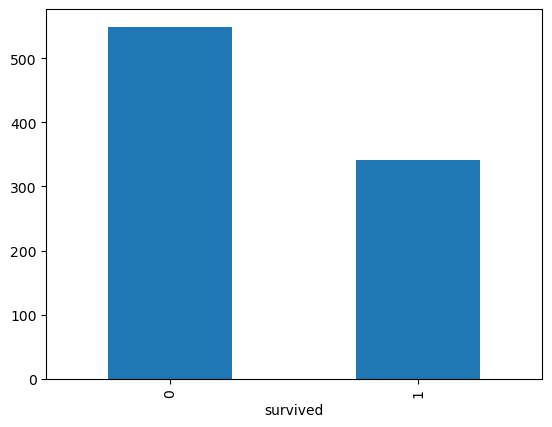

In [35]:
df_titan['survived'].value_counts().plot(kind = 'bar')

#### Data Preprocessing

In [36]:
#Splitting into target and features
X = df_titan.drop(columns = ['survived'])
y = df_titan['survived']

In [37]:
X.shape

(891, 6)

In [38]:
y.shape

(891,)

In [39]:
X.head()

,pclass,sex,age,fare,embarked,family_size
0,3,1,22.0,7.2500,1,2
1,1,0,38.0,71.2833,2,2
2,3,0,26.0,7.9250,1,1
3,1,0,35.0,53.1000,1,2
4,3,1,35.0,8.0500,1,1


In [40]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [42]:
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (712, 6)
Shape of X_test: (179, 6)
Shape of y_train: (712,)
Shape of y_test: (179,)


#### Model Building

##### Baseline Model

In [43]:
y_train.value_counts() 

survived
0    439
1    273
Name: count, dtype: int64

In [44]:
##we will need to normalize the value counts so we can see the proportion of those who died to those who survived and find the maximum
#The proportion of those who died to those who survived is 61:38(ie about 61% of the passengers died,while about 38% survived)

In [45]:
baseline_accuracy= y_train.value_counts(normalize=True).max()
baseline_accuracy

0.6165730337078652

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
titanic_model = LogisticRegression(max_iter=1000)

In [48]:
titanic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [49]:
train_predict = titanic_model.predict(X_train)
test_predict = titanic_model.predict(X_test)

#### Evaluation Metrics

In [50]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

In [51]:
accuracy_train = accuracy_score(y_train, train_predict)
accuracy_test = accuracy_score(y_test, test_predict)
recall_train = recall_score(y_train, train_predict)
recall_test = recall_score(y_test, test_predict)
f1_train = f1_score(y_train, train_predict)
f1_test = f1_score(y_test, test_predict)

print('Accuracy Training:', accuracy_train)
print('Accuracy Testing:', accuracy_test)
print('Recall Training:', recall_train)
print('Recall Testing:', recall_test)
print('F1 Training:', f1_train)
print('F1 Testing:', f1_test)

Accuracy Training: 0.8033707865168539
Accuracy Testing: 0.8044692737430168
Recall Training: 0.706959706959707
Recall Testing: 0.6956521739130435
F1 Training: 0.7338403041825095
F1 Testing: 0.732824427480916


#### Logistic Regression Model Performance & Interpretation

The Logistic Regression model built to predict Titanic passenger survival demonstrated excellent, highly stable performance:
 
 - Before building the model, a baseline was set by simply predicting the majority class ("Died") for every single passenger. Because 61.7% of passengers died, this blind guessing approach scores 61.66% accuracy automatically. Any useful model must be able to beat this number, otherwise it is worse than not thinking at all.
 - The Logistic Regression model achieved a test accuracy of 80.45%, which is an 18.79% improvement over the baseline. This confirms the model is genuinely learning patterns from the data (gender, class, age, fare) rather than just defaulting to the majority outcome.
 - Training accuracy of 80.34% and testing accuracy of 80.45% are almost identical, confirming the model is completely stable, free from overfitting, and capable of accurately predicting outcomes on data it has never encountered before.
 - The model correctly identifies 69.57% of actual survivors (Recall) with an F1-Score of 73.28%. It is better at predicting deaths than survivals, which is expected given that deaths outnumber survivals in the dataset. For a standard Logistic Regression without advanced tuning, this is a strong and balanced result.
 -  If deployed on a new list of Titanic-era passengers with similar features, this model would correctly classify roughly 4 out of every 5 passengers. It is not flawless, but it is far more reliable than guessing, and it identifies the key factors (gender, class, fare) that separated life from death.

##### Confusion Matrix

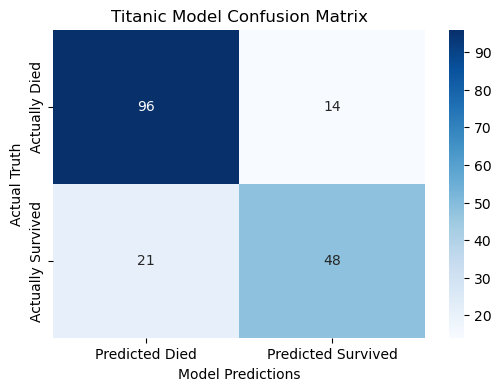

In [52]:
cm = confusion_matrix(y_test, test_predict)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Died', 'Predicted Survived'], 
            yticklabels=['Actually Died', 'Actually Survived'])

plt.title('Titanic Model Confusion Matrix')
plt.ylabel('Actual Truth')
plt.xlabel('Model Predictions')
plt.show()

The visual representation of the confusion matrix demonstrates that the model possesses strong predictive capabilities, 
with correct classifications heavily dominating the chart.

Out of 179 test passengers, the model correctly classified 144 of them, recording 96 true deaths and 48 true survivors, while making only 14 false survival predictions and 21 false death predictions, confirming that its 80.4% accuracy is driven by real pattern recognition and not random guessing.